# Wide screen of 15 second-order safety readouts — demo**Artifact:** pre-registered wide screen + one-shot blind confirmation of second-order *activation*readouts for safety, scored against the incumbent **final-layer logit gap** (`BL1_easy`).The full artifact registers 15 single-model activation candidates (W1–W8 write-handle/redundancy,G1–G4 dimensionless geometry, A1–A3 competing mechanisms), measures each on a 48-checkpoint gradedpanel, then runs1. **S3.2 pre-screen** — a candidate whose Spearman correlation with the incumbent logit gap is   `|rho| >= 0.50` across the panel is *collinear with the bar* and is DROPPED before any outcome is   looked at (in the real run: G2 +0.745, G1 −0.713, W8 +0.615, W6 +0.554 dropped, 11 kept);2. **S3.3 effective rank** — is the whole candidate family really one coordinate (hypothesis P1)?   In the real run it is not: `erank_entropy = 7.16` and `|cos(leading checkpoint singular vector,   z(BL1_easy))| = 0.645`, so P1 is NOT supported;3. **S6 assembly** (`method.py`) — every stage is folded into the `exp_gen_sol_out` document.This notebook runs exactly those three stages, with the original code from `src/statlib.py`,`src/prescreen.py` and `method.py`, on a curated 8-candidate × 12-checkpoint slice of the realscreen table. Nothing is re-measured from model weights here — the activation readouts were computedon GPU in the artifact; the demo replays the statistics stage on their stored values.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy, matplotlib — pre-installed on Colab, install locally to match Colab's versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


## ImportsThe original modules import only the standard library plus NumPy (`statlib.py` deliberatelyreimplements `rankdata`/Spearman so the screen has no SciPy dependency). `matplotlib` is addedfor the summary figures at the end.

In [2]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Callable, Sequence

import numpy as np
import matplotlib.pyplot as plt

## Data loading`mini_demo_data.json` is the curated subset of `results/screen_table.json`: 96 measured cells(8 candidates × 12 panel checkpoints), the incumbent `BL1_easy` bar value for each checkpoint, thepre-registered expected signs, and the bootstrap seed.

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-f8532e-safety-only-checks-output-when-warned/main/round-5/experiment-1/demo/mini_demo_data.json"

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()

print(data["description"])
print()
print("candidates :", data["candidates"])
print("checkpoints:", len(data["panel"]))
for t in data["panel"]:
    print("   ", t)
print("cells      :", len(data["examples"]))
print("bar meta   :", data["support"]["bar_meta"])

Curated subset of the iteration-5 wide-screen table: 8 of the 15 registered second-order activation readouts on 12 of the 48 graded panel checkpoints, plus the incumbent final-layer logit-gap bar (BL1_easy) for the same checkpoints.

candidates : ['G1', 'G2', 'W6', 'W8', 'W3', 'G4', 'G3', 'A3']
checkpoints: 12
    F1__a05
    F1__a10
    F1__cautious
    F2__a05
    F2__a10
    F2__cautious
    F3__a05
    F3__a10
    F3__cautious
    HG__Goekdeniz-Guelmez--Josiefied-Qwen2.5-1.5B-Instruct-abliterated-v3
    HG__Qwen--Qwen2.5-1.5B-Instruct
    HG__Qwen--Qwen3-1.7B
cells      : 96
bar meta   : {'array': 'r_refusal - r_control @ hidden-state index L (final layer)', 'layer': 'L=28', 'prompt_set': 'EASY n=96 (48 advbench-harmful vs 48 dolly-benign)'}


## ConfigEvery tunable of the demo lives here. `N_CHECKPOINTS` and `N_CANDIDATES` slice the demo panel;`N_BOOT` is the checkpoint-bootstrap replicate count. The values on the right in the comments arewhat the full artifact run used (48 checkpoints, 15 candidates, 2000 replicates) — the demo slice iscapped by what ships in `mini_demo_data.json`.

In [5]:
# ---- tunables -------------------------------------------------------------
N_CHECKPOINTS = 12          # full run: 48 graded panel checkpoints
N_CANDIDATES = 8            # full run: 15 registered candidates (W1-W8, G1-G4, A1-A3)
N_BOOT = 2000               # full run: 2000 checkpoint-bootstrap replicates
N_STABILITY_DRAWS = 8       # full run: all stored (prompt_draw x fold_seed x band_offset) draws
PRESCREEN_THRESHOLD = 0.50  # |rho| vs BL1_easy at or above this -> DROPPED as collinear
ERANK_ENTROPY_MAX = 1.5     # P1 thresholds, from the frozen pre-registration
ERANK_COS_MIN = 0.8
# ---------------------------------------------------------------------------

# prescreen.py globals, restricted to the candidates present in the demo slice
CANDIDATES = data["candidates"][:N_CANDIDATES]
TIER_A_CANDS = {"G1", "G2", "G3", "G4", "A3"}   # array-only pass, available on the full panel
PANEL = data["panel"][:N_CHECKPOINTS]
SEED = data["support"]["operationalisation_seed"]

print("CANDIDATES  :", CANDIDATES)
print("TIER-A here :", sorted(TIER_A_CANDS & set(CANDIDATES)))
print("PANEL       :", len(PANEL), "checkpoints")
print("SEED        :", SEED)

CANDIDATES  : ['G1', 'G2', 'W6', 'W8', 'W3', 'G4', 'G3', 'A3']
TIER-A here : ['A3', 'G1', 'G2', 'G3', 'G4']
PANEL       : 12 checkpoints
SEED        : 20260922


## Rebuilding the screen tableThe artifact's S3 stage reads `results/screen_table.json` from disk. Here the same structure —`{"panel": [...], "rows": [...], "bars": [...]}` — is rebuilt from the demo examples, so everyfunction below is called exactly as it is in the pipeline.

In [6]:
rows = []
for e in data["examples"]:
    key = json.loads(e["input"])
    if key["candidate"] not in CANDIDATES or key["tag"] not in PANEL:
        continue
    rows.append({
        "tag": key["tag"],
        "candidate": key["candidate"],
        "value": float(e["output"]),
        "tier": e["metadata_tier"],
        "censored": e["metadata_censored"],
        "flags": e["metadata_flags"],
        "band": e["metadata_band"],
        "n_prompts": e["metadata_n_prompts"],
        "stability": e["metadata_stability"][:N_STABILITY_DRAWS],
    })

bars = [{"tag": t, "bar": "BL1_easy", "value": data["support"]["bars_BL1_easy"][t],
         "meta": data["support"]["bar_meta"]} for t in PANEL]

screen_table = {"panel": PANEL, "rows": rows, "bars": bars}

# prereg.json, reduced to the two fields S3.2 reads out of it
prereg = {"d_candidates": {c: {"expected_sign": data["support"]["prereg_expected_sign"].get(c, {})}
                            for c in CANDIDATES},
          "operationalisation_seed": SEED}

print(f"{len(rows)} rows, {len(bars)} bar rows, {len(PANEL)} panel checkpoints")
print("example row:", json.dumps({k: v for k, v in rows[0].items() if k != 'stability'}))
print("stability draws on that row:", len(rows[0]["stability"]))

96 rows, 12 bar rows, 12 panel checkpoints
example row: {"tag": "F1__a05", "candidate": "G1", "value": 53.8166350177096, "tier": "A", "censored": false, "flags": [], "band": {"A": 4, "B": 6}, "n_prompts": 32}
stability draws on that row: 4


## `src/statlib.py` — the screen's statisticsCopied verbatim from the artifact. Spearman uses pairwise deletion; the bootstrap resamples**checkpoint indices** (which is what makes margins between candidates paired); `erank` returns boththe entropy effective rank `exp(-sum p log p)` and the participation ratio; `rho_mde` is theminimum detectable Spearman rho at alpha=0.05 / power 0.80; `winsorise_high` caps CENSORED_HIGHcells at the panel's 95th percentile.

In [7]:
def _rankdata(a: np.ndarray) -> np.ndarray:
    """Average-rank transform (identical to scipy.stats.rankdata method='average')."""
    a = np.asarray(a, dtype=float)
    n = a.size
    order = np.argsort(a, kind="mergesort")
    ranks = np.empty(n, dtype=float)
    sa = a[order]
    i = 0
    while i < n:
        j = i
        while j + 1 < n and sa[j + 1] == sa[i]:
            j += 1
        avg = 0.5 * (i + j) + 1.0
        ranks[order[i : j + 1]] = avg
        i = j + 1
    return ranks


def _pearson(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if x.size < 3:
        return float("nan")
    xc = x - x.mean()
    yc = y - y.mean()
    den = math.sqrt(float(xc @ xc) * float(yc @ yc))
    if den <= 0.0:
        return float("nan")
    return float((xc @ yc) / den)


def _finite_pair(x: Sequence[float], y: Sequence[float]) -> tuple[np.ndarray, np.ndarray]:
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    m = np.isfinite(x) & np.isfinite(y)
    return x[m], y[m]


def spearman(x: Sequence[float], y: Sequence[float]) -> dict:
    """Spearman rho with pairwise deletion. Returns {rho, n}."""
    xf, yf = _finite_pair(x, y)
    n = int(xf.size)
    if n < 3:
        return {"rho": float("nan"), "n": n}
    return {"rho": _pearson(_rankdata(xf), _rankdata(yf)), "n": n}


def checkpoint_bootstrap(
    stat_fn: Callable[[np.ndarray], float],
    n_items: int,
    *,
    n_boot: int = 2000,
    seed: int = 20260921,
    alpha: float = 0.05,
) -> dict:
    """Percentile bootstrap over CHECKPOINT indices.

    `stat_fn` receives an index array (with replacement) and returns a scalar.
    Every statistic in this artifact is computed on the SAME resampled index
    vector, which is what makes the margins paired.
    """
    rng = np.random.default_rng(seed)
    point = float(stat_fn(np.arange(n_items)))
    draws = np.empty(n_boot, dtype=float)
    for b in range(n_boot):
        idx = rng.integers(0, n_items, size=n_items)
        try:
            draws[b] = float(stat_fn(idx))
        except (ValueError, ZeroDivisionError, np.linalg.LinAlgError):
            draws[b] = np.nan
    good = draws[np.isfinite(draws)]
    if good.size < 50:
        return {
            "point": point,
            "lo": float("nan"),
            "hi": float("nan"),
            "n_boot_ok": int(good.size),
            "excludes_zero": False,
        }
    lo = float(np.quantile(good, alpha / 2.0))
    hi = float(np.quantile(good, 1.0 - alpha / 2.0))
    return {
        "point": point,
        "lo": lo,
        "hi": hi,
        "n_boot_ok": int(good.size),
        "excludes_zero": bool((lo > 0.0) or (hi < 0.0)),
    }


def erank(matrix: np.ndarray) -> dict:
    """Effective rank of a (candidates x checkpoints) matrix.

    Returns both the entropy variant exp(-sum p log p) and the participation
    ratio (sum s^2)^2 / sum s^4, plus the singular-value spectrum and the
    leading right/left singular vectors.
    """
    m = np.asarray(matrix, dtype=float)
    if m.ndim != 2 or min(m.shape) < 2:
        return {"erank_entropy": float("nan"), "erank_participation": float("nan"),
                "singular_values": [], "explained": [], "leading_left": []}
    u, s, _vt = np.linalg.svd(m, full_matrices=False)
    s2 = s**2
    tot = float(s2.sum())
    if tot <= 0.0:
        return {"erank_entropy": float("nan"), "erank_participation": float("nan"),
                "singular_values": s.tolist(), "explained": [], "leading_left": []}
    p = s2 / tot
    nz = p[p > 1e-15]
    ent = float(np.exp(-float(np.sum(nz * np.log(nz)))))
    part = float((tot**2) / float(np.sum(s2**2)))
    return {
        "erank_entropy": ent,
        "erank_participation": part,
        "singular_values": s.tolist(),
        "explained": p.tolist(),
        "leading_left": u[:, 0].tolist(),
    }


def rho_mde(n: int) -> float:
    """Minimum detectable Spearman rho, two-sided alpha=0.05, power 0.80.

    rho_MDE = tanh(2.80 / sqrt(n - 3))   (Fisher-z, z_{.975}+z_{.80} = 2.80)
    """
    if n is None or n <= 3:
        return float("nan")
    return float(math.tanh(2.80 / math.sqrt(n - 3.0)))


def winsorise_high(values: Sequence[float], censored: Sequence[bool]) -> np.ndarray:
    """Replace CENSORED_HIGH cells with the panel's 95th percentile of the
    uncensored finite values. Returns a new array; never mutates the input."""
    v = np.asarray(values, dtype=float).copy()
    cen = np.asarray(censored, dtype=bool)
    ok = np.isfinite(v) & (~cen)
    if ok.sum() >= 3:
        cap = float(np.quantile(v[ok], 0.95))
    elif ok.sum() > 0:
        cap = float(np.nanmax(v[ok]))
    else:
        return v
    v[cen] = cap
    return v


print("statlib loaded; MDE at n =", len(PANEL), "->", round(rho_mde(len(PANEL)), 4))

statlib loaded; MDE at n = 12 -> 0.7321


## S3.2 — the pre-screen (`src/prescreen.py`)For each candidate: winsorise censored cells (except W2, whose sentinel 7 is a meaningful ceilingcode), take Spearman against `BL1_easy` over the panel, bootstrap a CI over checkpoints, also reportthe censored-dropped variant and the sign stability of the stored re-draws. `|rho| >= 0.50` ⇒**DROPPED** as collinear with the incumbent bar.In the artifact this whole block runs inside a hardened `open()` audit that makes reading anyoutcome file (`graded_truth`, `classification`, `heldout`, …) raise `PermissionError` — the demodrops the audit wrapper only because there is no filesystem to guard here.

In [8]:
def _row_values(rows: list[dict], cand: str, panel: list[str]) -> dict[str, dict]:
    """tag -> {'value':.., 'censored':bool} for a candidate, panel rows only."""
    out = {}
    for r in rows:
        if r["candidate"] != cand or r["tag"] not in panel:
            continue
        out[r["tag"]] = {"value": r["value"], "censored": bool(r.get("censored", False))}
    return out


def _expected_sign(prereg: dict, cand: str) -> str | None:
    d = prereg.get("d_candidates", {}).get(cand, {})
    es = d.get("expected_sign", {})
    hc = es.get("HC")
    if hc is None:
        return None
    hc = str(hc).strip()
    if hc.startswith("-"):
        return "-"
    if hc.startswith("+"):
        return "+"
    return hc[:1] if hc else None


def _sign_stability(rows: list[dict], cand: str, panel: list[str]) -> dict:
    """From screen_table stability draws (when present): fraction of (row, draw) pairs
    whose sign matches the row's registered value sign."""
    n_agree, n_total = 0, 0
    for r in rows:
        if r["candidate"] != cand or r["tag"] not in panel:
            continue
        reg = r.get("value")
        draws = r.get("stability")
        if reg is None or not isinstance(draws, list) or not draws:
            continue
        reg_sign = np.sign(reg)
        if reg_sign == 0:
            continue
        for d in draws:
            v = d.get("value")
            if v is None or not np.isfinite(v):
                continue
            n_total += 1
            if np.sign(v) == reg_sign:
                n_agree += 1
    if n_total == 0:
        return {"sign_agree_frac": None, "n_draws": 0}
    return {"sign_agree_frac": n_agree / n_total, "n_draws": n_total}


def run_s3_2(prereg: dict, screen_table: dict) -> dict:
    panel = list(screen_table.get("panel", []))
    rows = screen_table.get("rows", [])

    # BL1_easy per tag, from the bars table (bar == "BL1_easy").
    bl1 = {}
    for b in screen_table.get("bars", []):
        if b.get("bar") == "BL1_easy" and b.get("tag") not in bl1:
            bl1[b["tag"]] = b.get("value")

    out = {}
    n_dropped = n_kept = n_not_evaluable = 0
    for cand in CANDIDATES:
        vals = _row_values(rows, cand, panel)
        tags_ordered = [t for t in panel if t in vals]
        raw = np.array([vals[t]["value"] if vals[t]["value"] is not None else np.nan for t in tags_ordered], dtype=float)
        cen = np.array([vals[t]["censored"] for t in tags_ordered], dtype=bool)
        y_raw = np.array([bl1.get(t, np.nan) for t in tags_ordered], dtype=float)

        # censoring rule: winsorise at panel-95th-pct of uncensored values, EXCEPT W2 keeps its
        # sentinel 7 (never winsorised -- it is a meaningful ceiling code, not an outlier).
        if cand == "W2":
            wins = raw.copy()
        else:
            wins = winsorise_high(raw, cen) if cen.any() else raw

        sp_w = spearman(wins, y_raw)
        n = sp_w["n"]

        def _stat(idx, a=wins, b=y_raw):
            return spearman(a[idx], b[idx])["rho"]

        ci = checkpoint_bootstrap(_stat, len(wins), n_boot=N_BOOT,
                                   seed=prereg["operationalisation_seed"]) if len(wins) >= 5 else \
            {"point": sp_w["rho"], "lo": float("nan"), "hi": float("nan"), "n_boot_ok": 0, "excludes_zero": False}

        # censored-dropped variant
        keep = ~cen
        sp_dropped = spearman(raw[keep], y_raw[keep])

        mde = rho_mde(n) if n and n > 3 else float("nan")
        expected = _expected_sign(prereg, cand)
        stability = _sign_stability(rows, cand, panel)

        evaluable = n >= 3 and np.isfinite(sp_w["rho"])
        if not evaluable:
            status = "NOT_EVALUABLE"
            n_not_evaluable += 1
        elif abs(sp_w["rho"]) >= PRESCREEN_THRESHOLD:
            status = "DROPPED"
            n_dropped += 1
        else:
            status = "KEPT"
            n_kept += 1

        out[cand] = {
            "rho": sp_w["rho"], "ci": {"lo": ci["lo"], "hi": ci["hi"], "n_boot_ok": ci.get("n_boot_ok")},
            "n": n, "mde": mde, "status": status,
            "rho_censored_dropped": sp_dropped["rho"], "n_censored_dropped": sp_dropped["n"],
            "n_censored": int(cen.sum()), "tier": "Tier-A-only" if cand in TIER_A_CANDS else "mixed/Tier-B",
            "stable_flags": stability, "expected_sign_HC": expected,
        }

    return {
        "threshold": PRESCREEN_THRESHOLD,
        "prescreen_rule": "|Spearman(candidate, BL1_easy)| over screen-panel rows with both finite >= 0.50 -> DROPPED",
        "candidates": out,
        "n_dropped": n_dropped, "n_kept": n_kept, "n_not_evaluable": n_not_evaluable,
        "n_panel": len(panel),
    }


prescreen_result = run_s3_2(prereg, screen_table)
print(f"S3.2: dropped={prescreen_result['n_dropped']} kept={prescreen_result['n_kept']} "
      f"not_evaluable={prescreen_result['n_not_evaluable']}")
for cand, rec in prescreen_result["candidates"].items():
    print(f"  {cand:<3} rho={rec['rho']:+.3f}  CI[{rec['ci']['lo']:+.3f},{rec['ci']['hi']:+.3f}]  "
          f"n={rec['n']:>2}  MDE={rec['mde']:.3f}  {rec['status']}")

S3.2: dropped=3 kept=5 not_evaluable=0
  G1  rho=-0.629  CI[-0.913,-0.119]  n=12  MDE=0.732  DROPPED
  G2  rho=+0.587  CI[+0.000,+0.941]  n=12  MDE=0.732  DROPPED
  W6  rho=+0.105  CI[-0.640,+0.774]  n=12  MDE=0.732  KEPT
  W8  rho=+0.469  CI[-0.080,+0.863]  n=12  MDE=0.732  KEPT
  W3  rho=+0.049  CI[-0.740,+0.690]  n=12  MDE=0.732  KEPT
  G4  rho=+0.497  CI[-0.177,+0.839]  n=12  MDE=0.732  KEPT
  G3  rho=+0.538  CI[-0.081,+0.851]  n=12  MDE=0.732  DROPPED
  A3  rho=-0.280  CI[-0.674,+0.324]  n=12  MDE=0.732  KEPT


## S3.3 — effective rank (is the family one coordinate?)Each candidate row is z-scored over its finite entries (NaN → 0 after z-scoring = mean imputation),then the (candidates × checkpoints) matrix is decomposed. `erank_partial_BL1` repeats thedecomposition on the OLS residuals of every row on `z(BL1_easy)`, and the leading **right** singularvector (checkpoint loadings) is compared to `z(BL1_easy)` by absolute cosine.Hypothesis **P1** ("all of this is one coordinate, and that coordinate is the logit gap") survivesonly if `erank_entropy <= 1.5` **and** `|cos| >= 0.8`.

In [9]:
def _zscore_impute(mat: np.ndarray) -> tuple[np.ndarray, int]:
    """z-score each ROW (candidate) over its finite entries; NaN -> 0 AFTER z-scoring
    (mean imputation). Returns (matrix, n_imputed)."""
    m = mat.copy()
    n_imputed = 0
    for i in range(m.shape[0]):
        row = m[i]
        finite = np.isfinite(row)
        if finite.sum() >= 2:
            mu = row[finite].mean()
            sd = row[finite].std(ddof=0) or 1.0
            m[i] = (row - mu) / sd
        else:
            m[i] = 0.0
        bad = ~np.isfinite(m[i])
        n_imputed += int(bad.sum())
        m[i, bad] = 0.0
    return m, n_imputed


def _partial_out_bl1(mat_z: np.ndarray, y_z: np.ndarray) -> np.ndarray:
    """Replace each row by its OLS residual on z(BL1_easy) (with intercept)."""
    out = np.zeros_like(mat_z)
    design = np.column_stack([np.ones_like(y_z), y_z])
    for i in range(mat_z.shape[0]):
        beta, *_ = np.linalg.lstsq(design, mat_z[i], rcond=None)
        out[i] = mat_z[i] - design @ beta
    return out


def _build_matrix(rows: list[dict], cands: list[str], tags: list[str]) -> np.ndarray:
    idx = {(r["tag"], r["candidate"]): r["value"] for r in rows}
    m = np.full((len(cands), len(tags)), np.nan, dtype=float)
    for i, c in enumerate(cands):
        for j, t in enumerate(tags):
            v = idx.get((t, c))
            if v is not None:
                m[i, j] = v
    return m


def _spearman_matrix(mat_raw: np.ndarray, cands: list[str]) -> dict:
    n = len(cands)
    out = {}
    for i in range(n):
        for j in range(n):
            r = spearman(mat_raw[i], mat_raw[j])
            out[f"{cands[i]}|{cands[j]}"] = r["rho"]
    return out


def _rank_block(rows: list[dict], cands: list[str], tags: list[str], bl1_by_tag: dict) -> dict:
    mat_raw = _build_matrix(rows, cands, tags)
    mat_z, n_imputed = _zscore_impute(mat_raw)
    y_raw = np.array([bl1_by_tag.get(t, np.nan) for t in tags], dtype=float)
    y_finite = np.isfinite(y_raw)
    y_z = np.zeros_like(y_raw)
    if y_finite.sum() >= 2:
        mu, sd = y_raw[y_finite].mean(), (y_raw[y_finite].std(ddof=0) or 1.0)
        y_z[y_finite] = (y_raw[y_finite] - mu) / sd
    # y NaNs -> 0 too (same imputation convention)

    full = erank(mat_z)
    mat_partial = _partial_out_bl1(mat_z, y_z)
    partial = erank(mat_partial)

    # leading right singular vector (checkpoint loadings) -> |cos| with z(BL1_easy)
    if mat_z.shape[0] >= 2 and mat_z.shape[1] >= 2:
        _u, _s, vt = np.linalg.svd(mat_z, full_matrices=False)
        v1 = vt[0]
        denom = (np.linalg.norm(v1) * np.linalg.norm(y_z)) or 1.0
        cos_ckpt_bl1 = abs(float(np.dot(v1, y_z) / denom)) if denom else float("nan")
    else:
        cos_ckpt_bl1 = float("nan")

    return {
        "n_candidates": len(cands), "n_checkpoints": len(tags), "n_imputed": n_imputed,
        "candidates": cands, "checkpoints": tags,
        "erank_full": {"erank_entropy": full["erank_entropy"], "erank_participation": full["erank_participation"],
                        "singular_values": full["singular_values"], "leading_left_loadings": full["leading_left"]},
        "erank_partial_BL1": {"erank_entropy": partial["erank_entropy"],
                               "erank_participation": partial["erank_participation"],
                               "singular_values": partial["singular_values"],
                               "leading_left_loadings": partial["leading_left"]},
        "leading_eigenvector_loading_pattern": dict(zip(cands, full["leading_left"])) if full["leading_left"] else {},
        "abs_cos_leading_right_singvec_vs_zBL1": cos_ckpt_bl1,
        "spearman_matrix": _spearman_matrix(mat_raw, cands),
    }


def run_s3_3(prereg: dict, screen_table: dict) -> dict:
    panel = list(screen_table.get("panel", []))
    rows = screen_table.get("rows", [])
    bl1 = {}
    for b in screen_table.get("bars", []):
        if b.get("bar") == "BL1_easy" and b.get("tag") not in bl1:
            bl1[b["tag"]] = b.get("value")

    full_panel_block = _rank_block(rows, CANDIDATES, panel, bl1)

    tierA_block = _rank_block(rows, sorted(TIER_A_CANDS & set(CANDIDATES)), panel, bl1)

    # complete-Tier-B-coverage: checkpoints where EVERY candidate (incl. Tier-B) is finite
    idx = {(r["tag"], r["candidate"]): r["value"] for r in rows}
    complete_tags = [t for t in panel
                     if all(idx.get((t, c)) is not None and np.isfinite(idx[(t, c)]) for c in CANDIDATES)]
    if len(complete_tags) >= 2:
        complete_block = _rank_block(rows, CANDIDATES, complete_tags, bl1)
    else:
        complete_block = {"note": f"only {len(complete_tags)} checkpoints have complete Tier-B coverage "
                                   f"(need >=2 for SVD); block skipped", "n_checkpoints": len(complete_tags)}

    ent = full_panel_block["erank_full"]["erank_entropy"]
    cos = full_panel_block["abs_cos_leading_right_singvec_vs_zBL1"]
    if np.isfinite(ent) and np.isfinite(cos) and ent <= ERANK_ENTROPY_MAX and cos >= ERANK_COS_MIN:
        verdict = "P1-consistent: one coordinate, BL1-aligned"
    elif np.isfinite(ent) and np.isfinite(cos):
        verdict = (f"P1 NOT supported by the rank structure: erank_entropy={ent:.3f} "
                   f"(threshold <={ERANK_ENTROPY_MAX}), |cos(leading ckpt singvec, z(BL1_easy))|={cos:.3f} "
                   f"(threshold >={ERANK_COS_MIN})")
    else:
        verdict = "erank/cos not computable (insufficient finite data)"

    return {
        "full_panel_all_candidates": full_panel_block,
        "tier_A_only_full_panel": tierA_block,
        "complete_tierB_coverage": complete_block,
        "verdict": verdict,
    }


rank_result = run_s3_3(prereg, screen_table)
fb = rank_result["full_panel_all_candidates"]
print("erank entropy       :", round(fb["erank_full"]["erank_entropy"], 3))
print("erank participation :", round(fb["erank_full"]["erank_participation"], 3))
print("erank after partialling out BL1_easy:",
      round(fb["erank_partial_BL1"]["erank_entropy"], 3))
print("|cos(leading ckpt singvec, z(BL1_easy))| :",
      round(fb["abs_cos_leading_right_singvec_vs_zBL1"], 3))
print()
print("VERDICT:", rank_result["verdict"])

erank entropy       : 3.865
erank participation : 2.763
erank after partialling out BL1_easy: 4.181
|cos(leading ckpt singvec, z(BL1_easy))| : 0.609

VERDICT: P1 NOT supported by the rank structure: erank_entropy=3.865 (threshold <=1.5), |cos(leading ckpt singvec, z(BL1_easy))|=0.609 (threshold >=0.8)


## S6 — assembly (`method.py`)`method.py` is the final aggregation stage: every results file becomes one dataset of`exp_gen_sol_out` examples. The builders below are copied verbatim; they are fed the S3.2/S3.3results just computed instead of the JSON files on disk.

In [10]:
def _ex(input_obj, output, **kw) -> dict:
    """Build one exp_gen_sol_out example; predict_/metadata_ kwargs are cast to str/JSON as required."""
    e = {"input": json.dumps(input_obj, sort_keys=True), "output": str(output)}
    for k, v in kw.items():
        if k.startswith("predict_"):
            e[k] = "" if v is None else str(v)
        elif k.startswith("metadata_"):
            e[k] = v
    return e


def build_screen_table_dataset(screen_table: dict | None) -> dict:
    examples = []
    if screen_table:
        for r in screen_table.get("rows", []):
            examples.append(_ex(
                {"tag": r["tag"], "candidate": r["candidate"]}, r.get("value"),
                metadata_tier=r.get("tier"), metadata_censored=r.get("censored"),
                metadata_flags=r.get("flags"), metadata_band=r.get("band"),
                metadata_n_prompts=r.get("n_prompts"),
            ))
    if not examples:
        examples = [_ex({"note": "screen_table.json not available"}, "N/A")]
    return {"dataset": "screen_table", "examples": examples}


def build_prescreen_dataset(prescreen: dict | None) -> dict:
    examples = []
    if prescreen:
        for cand, rec in prescreen.get("candidates", {}).items():
            examples.append(_ex(
                {"candidate": cand}, rec.get("status"),
                metadata_rho=rec.get("rho"), metadata_ci=rec.get("ci"), metadata_n=rec.get("n"),
                metadata_mde=rec.get("mde"), metadata_tier=rec.get("tier"),
                predict_rho_BL1_easy=rec.get("rho"),
                predict_rho_censored_dropped=rec.get("rho_censored_dropped"),
            ))
    if not examples:
        examples = [_ex({"note": "prescreen.json not available"}, "N/A")]
    return {"dataset": "prescreen", "examples": examples}


def build_rank_analysis_dataset(rank: dict | None) -> dict:
    examples = []
    if rank:
        for block_name in ("full_panel_all_candidates", "tier_A_only_full_panel", "complete_tierB_coverage"):
            b = rank.get(block_name, {})
            if "erank_full" not in b:
                continue
            examples.append(_ex(
                {"block": block_name}, rank.get("verdict"),
                metadata_erank_entropy=b["erank_full"].get("erank_entropy"),
                metadata_erank_participation=b["erank_full"].get("erank_participation"),
                metadata_erank_entropy_partial_BL1=b.get("erank_partial_BL1", {}).get("erank_entropy"),
                metadata_abs_cos_ckpt_vs_zBL1=b.get("abs_cos_leading_right_singvec_vs_zBL1"),
                metadata_n_candidates=b.get("n_candidates"), metadata_n_checkpoints=b.get("n_checkpoints"),
            ))
    if not examples:
        examples = [_ex({"note": "rank_analysis.json not available"}, "N/A")]
    return {"dataset": "rank_analysis", "examples": examples}


def build_stability_dataset(screen_table: dict | None) -> dict:
    examples = []
    if screen_table:
        for r in screen_table.get("rows", []):
            stab = r.get("stability")
            if not isinstance(stab, list) or not stab:
                continue
            vals = [d["value"] for d in stab if isinstance(d, dict) and d.get("value") is not None]
            reg = r.get("value")
            agree = None
            if vals and reg is not None:
                agree = float(sum(1 for v in vals if (v >= 0) == (reg >= 0)) / len(vals))
            examples.append(_ex(
                {"tag": r["tag"], "candidate": r["candidate"]}, reg,
                metadata_n_draws=len(stab), metadata_sign_agree_frac=agree,
            ))
    if not examples:
        examples = [_ex({"note": "no stability draws available"}, "N/A")]
    return {"dataset": "stability", "examples": examples}


metadata = {
    "method_name": "iter5_wide_screen_and_confirmation_join (demo slice)",
    "description": "S3 pre-screen/effective-rank -> S6 output, on the curated demo slice.",
    "n_panel_checkpoints": len(screen_table["panel"]),
    "n_candidates_registered": len(CANDIDATES),
    "prescreen_n_dropped": prescreen_result["n_dropped"],
    "prescreen_n_kept": prescreen_result["n_kept"],
    "rank_analysis_verdict": rank_result["verdict"],
}

datasets = [
    build_screen_table_dataset(screen_table),
    build_prescreen_dataset(prescreen_result),
    build_rank_analysis_dataset(rank_result),
    build_stability_dataset(screen_table),
]

demo_out = {"metadata": metadata, "datasets": datasets}
print(json.dumps(metadata, indent=1)[:900])
print()
for d in datasets:
    print(f"  {d['dataset']:<14} {len(d['examples']):>4} examples")

{
 "method_name": "iter5_wide_screen_and_confirmation_join (demo slice)",
 "description": "S3 pre-screen/effective-rank -> S6 output, on the curated demo slice.",
 "n_panel_checkpoints": 12,
 "n_candidates_registered": 8,
 "prescreen_n_dropped": 3,
 "prescreen_n_kept": 5,
 "rank_analysis_verdict": "P1 NOT supported by the rank structure: erank_entropy=3.865 (threshold <=1.5), |cos(leading ckpt singvec, z(BL1_easy))|=0.609 (threshold >=0.8)"
}

  screen_table     96 examples
  prescreen         8 examples
  rank_analysis     3 examples
  stability        96 examples


## Results1. **Pre-screen table** — rho against the incumbent logit gap, its bootstrap CI, MDE and verdict.2. **|rho| bar chart** — which candidates are collinear with the bar (above the 0.50 line) and which   carry independent signal.3. **Candidate × checkpoint z-matrix** — the matrix the effective rank is computed on.4. **Singular-value spectrum** — before and after partialling out `z(BL1_easy)`. A family that were   "one coordinate" would put nearly all mass on the first singular value.

*Note:* these numbers are the demo slice (8 candidates × 12 checkpoints), not the 48-checkpoint / 15-candidate figures quoted in the paper — the pre-screen rho and the effective rank both move with the panel. The qualitative result is the same: the geometry candidates that track the logit gap are dropped, and the family is not one coordinate.

cand tier           rho vs BL1              95% CI  rho (cens.drop)     MDE  sign-stab  status
----------------------------------------------------------------------------------------------
G1   Tier-A-only        -0.629       [-0.91,-0.12]           -0.629   0.732       1.00  DROPPED
G2   Tier-A-only        +0.587       [+0.00,+0.94]           +0.587   0.732       1.00  DROPPED
W6   mixed/Tier-B       +0.105       [-0.64,+0.77]           +0.105   0.732       0.75  KEPT
W8   mixed/Tier-B       +0.469       [-0.08,+0.86]           +0.469   0.732       1.00  KEPT
W3   mixed/Tier-B       +0.049       [-0.74,+0.69]           +0.049   0.732       1.00  KEPT
G4   Tier-A-only        +0.497       [-0.18,+0.84]           +0.497   0.732       1.00  KEPT
G3   Tier-A-only        +0.538       [-0.08,+0.85]           +0.538   0.732       0.94  DROPPED
A3   Tier-A-only        -0.280       [-0.67,+0.32]           -0.355   0.732       1.00  KEPT

VERDICT: P1 NOT supported by the rank structure: erank_e

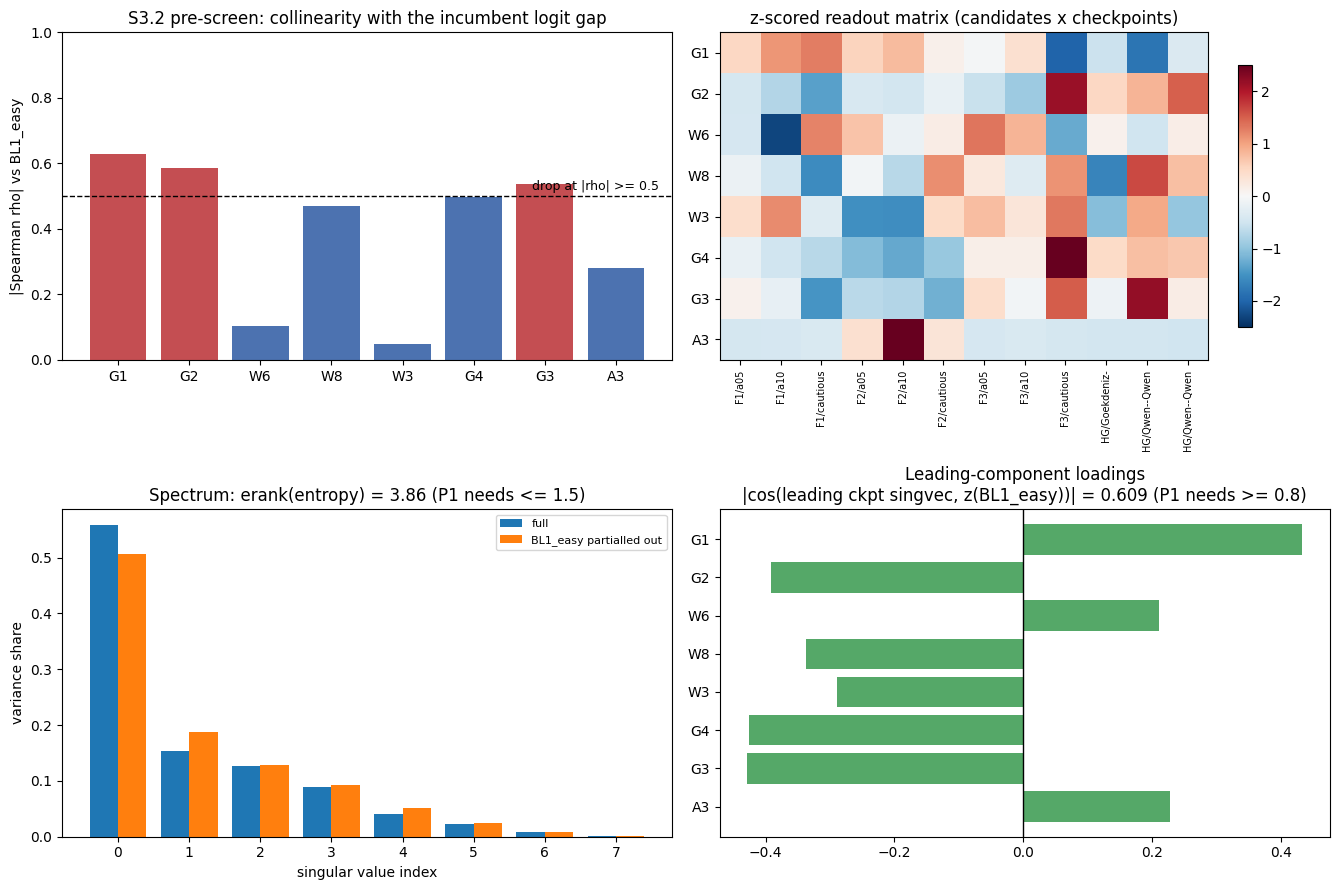

In [11]:
# ---- 1. pre-screen table --------------------------------------------------
hdr = f"{'cand':<5}{'tier':<14}{'rho vs BL1':>11}{'95% CI':>20}{'rho (cens.drop)':>17}{'MDE':>8}{'sign-stab':>11}  status"
print(hdr)
print("-" * len(hdr))
for cand, rec in prescreen_result["candidates"].items():
    ss = rec["stable_flags"]["sign_agree_frac"]
    print(f"{cand:<5}{rec['tier']:<14}{rec['rho']:>+11.3f}"
          f"{'[' + format(rec['ci']['lo'], '+.2f') + ',' + format(rec['ci']['hi'], '+.2f') + ']':>20}"
          f"{rec['rho_censored_dropped']:>+17.3f}{rec['mde']:>8.3f}"
          f"{('n/a' if ss is None else format(ss, '.2f')):>11}  {rec['status']}")
print()
print("VERDICT:", rank_result["verdict"])

fig, axes = plt.subplots(2, 2, figsize=(13.5, 9))

# ---- 2. |rho| vs the pre-screen threshold ---------------------------------
ax = axes[0, 0]
cands = list(prescreen_result["candidates"])
rhos = [prescreen_result["candidates"][c]["rho"] for c in cands]
cols = ["#c44e52" if abs(r) >= PRESCREEN_THRESHOLD else "#4c72b0" for r in rhos]
ax.bar(cands, [abs(r) for r in rhos], color=cols)
ax.axhline(PRESCREEN_THRESHOLD, ls="--", c="k", lw=1)
ax.text(len(cands) - 0.4, PRESCREEN_THRESHOLD + 0.02, f"drop at |rho| >= {PRESCREEN_THRESHOLD}",
        ha="right", fontsize=9)
ax.set_title("S3.2 pre-screen: collinearity with the incumbent logit gap")
ax.set_ylabel("|Spearman rho| vs BL1_easy")
ax.set_ylim(0, 1)

# ---- 3. candidate x checkpoint z-matrix -----------------------------------
ax = axes[0, 1]
mat_raw = _build_matrix(screen_table["rows"], CANDIDATES, PANEL)
mat_z, _ = _zscore_impute(mat_raw)
im = ax.imshow(mat_z, cmap="RdBu_r", vmin=-2.5, vmax=2.5, aspect="auto")
ax.set_yticks(range(len(CANDIDATES)), CANDIDATES)
ax.set_xticks(range(len(PANEL)), [t.split("__")[0] + "/" + t.split("__")[1][:10] for t in PANEL],
              rotation=90, fontsize=7)
ax.set_title("z-scored readout matrix (candidates x checkpoints)")
fig.colorbar(im, ax=ax, shrink=0.8)

# ---- 4. singular-value spectrum -------------------------------------------
ax = axes[1, 0]
sv = np.array(fb["erank_full"]["singular_values"])
svp = np.array(fb["erank_partial_BL1"]["singular_values"])
w = 0.4
ax.bar(np.arange(len(sv)) - w / 2, sv**2 / (sv**2).sum(), w, label="full")
ax.bar(np.arange(len(svp)) + w / 2, svp**2 / (svp**2).sum(), w, label="BL1_easy partialled out")
ax.set_xlabel("singular value index")
ax.set_ylabel("variance share")
ax.set_title(f"Spectrum: erank(entropy) = {fb['erank_full']['erank_entropy']:.2f} "
             f"(P1 needs <= {ERANK_ENTROPY_MAX})")
ax.legend(fontsize=8)

# ---- 5. loading of each candidate on the leading component ----------------
ax = axes[1, 1]
load = fb["leading_eigenvector_loading_pattern"]
ax.barh(list(load), [load[c] for c in load], color="#55a868")
ax.axvline(0, c="k", lw=1)
ax.set_title(f"Leading-component loadings\n|cos(leading ckpt singvec, z(BL1_easy))| = "
             f"{fb['abs_cos_leading_right_singvec_vs_zBL1']:.3f} (P1 needs >= {ERANK_COS_MIN})")
ax.invert_yaxis()

fig.tight_layout()
plt.show()